# Explore Sentiment of Corpus using a lexicon

Notes:

I am following along with my M10 Sentiment Analysis of Novels Notes as I complete this section.

## Setup

### Import Libraries

In [362]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

### Configure

In [363]:
# specify OHCO and bags
OHCO = ['book_id', 'chap_num', 'para_num', 'sent_num', 'token_num']

bags = dict(
    SENTS = OHCO[:4],
    PARAS = OHCO[:3],
    CHAPS = OHCO[:2],
    BOOKS = OHCO[:1]
)

In [364]:
salex_cols = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 
              'negative', 'positive', 'sadness', 'surprise', 'trust', 'sentiment']

### Load Data

In [365]:
# get NRC lexicon
SALEX = pd.read_csv('data/salex_nrc.csv').set_index('term_str')
SALEX.columns = [col.replace('nrc_','') for col in SALEX.columns]

SALEX

,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,sentiment
term_str,,,,,,,,,,,
abandon,0,0,0,1,0,1,0,1,0,0,-1
abandoned,1,0,0,1,0,1,0,1,0,0,-1
abandonment,1,0,0,1,0,1,0,1,1,0,-1
abduction,0,0,0,1,0,1,0,1,1,0,-1
aberration,0,0,1,0,0,1,0,0,0,0,-1
...,...,...,...,...,...,...,...,...,...,...,...
young,0,1,0,0,1,0,1,0,1,0,1
youth,1,1,0,1,1,0,1,0,1,0,1
zeal,0,1,0,0,1,0,1,0,1,1,1


This is a sentiment analysis table.

(Future attempts may use SentiWordNet instead.)

In [366]:
# load in tables
LIB = pd.read_csv('data/LIB.csv', sep='\t').set_index('book_id')
CORPUS = pd.read_csv('data/CORPUS.csv', sep='\t').set_index(OHCO)
VOCAB = pd.read_csv('data/VOCAB.csv', sep='\t').set_index('term_str')
BOW_chaps = pd.read_csv('data/BOW_chaps.csv', sep='\t')

## Apply the Model

### VOCAB_SENT

In [367]:
# join sentiment analysis table (SALEX) to VOCAB table
# filter out stop words and filter for POS that carry sentiment
sentiment_pos_groups = ['JJ', 'NN', 'VB', 'RB']
exclude_pos = ['NNP', 'NNPS']

VOCAB_SENT = VOCAB[
    (VOCAB['stop'] == False) & 
    (VOCAB['max_pos_group'].isin(sentiment_pos_groups)) &
    (~VOCAB['max_pos'].isin(exclude_pos))
].join(SALEX, on='lemma', how='inner')

VOCAB_SENT

,n,n_chars,p,i,max_pos,max_pos_group,lemma,n_pos_group,n_pos,stop,...,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,sentiment
term_str,,,,,,,,,,,,,,,,,,,,,
abandon,6,7,0.000007,17.104609,VB,VB,abandon,2,3,False,...,0,0,1,0,1,0,1,0,0,-1
abandoned,19,9,0.000022,15.441644,VBN,VB,abandon,1,2,False,...,0,0,1,0,1,0,1,0,0,-1
abandoning,7,10,0.000008,16.882217,VBG,VB,abandon,1,1,False,...,0,0,1,0,1,0,1,0,0,-1
abandonment,1,11,0.000001,19.689571,NN,NN,abandonment,1,1,False,...,0,0,1,0,1,0,1,1,0,-1
abduction,4,9,0.000005,17.689571,NN,NN,abduction,1,1,False,...,0,0,1,0,1,0,1,1,0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
youth,34,5,0.000040,14.602109,NN,NN,youth,2,3,False,...,1,0,1,1,0,1,0,1,0,1
youths,1,6,0.000001,19.689571,NNS,NN,youth,1,1,False,...,1,0,1,1,0,1,0,1,0,1
zeal,7,4,0.000008,16.882217,NN,NN,zeal,1,1,False,...,1,0,0,1,0,1,0,1,1,1


In [368]:
# what percent of corpus tokens is my sentiment analysis seeing
matched_tokens = VOCAB.loc[VOCAB_SENT.index, 'n'].sum()
total_tokens = VOCAB['n'].sum()
print(matched_tokens / total_tokens)

0.061706012720353275


In [369]:
content_vocab = VOCAB[VOCAB['stop'] == False]
matched_content = content_vocab.loc[content_vocab.index.intersection(VOCAB_SENT.index), 'n'].sum()
total_content = content_vocab['n'].sum()
print(matched_content / total_content)

0.1312922893427711


Original run checks:
- 0.055264933891233034 of corpus tokens my SA is seeing
- 0.12115644893191092 of content word tokens are covered

It appears that I will need to lemmatize to get better coverage of content word tokens. I shall be adding spaCy lemmatization to my CORPUS notebook. I will in fact be taking this as my motivation to swap to spaCy en_core_web_lg.

I made small improvements to 6.7% overall coverage and 14.2% coverage on content words.

Then, after filtering POS, I now have 6.2% overall coverage and 13.1% coverage on content words.

For transparency, it is worth noting that NRC lexicon covers approximately 13% of content word tokens in my corpus, reflecting both the lexicon's general-English scope and spaCy's POS-driven lemmatization, which ends up classifying many emotionally salient participial adjectives as non-verbal forms which don't reduce to their base entries in NRC.

The coverage reflects 3 decisions:
- restricting VOCAB_SENT to content POS groups and excluding proper nouns (removed noise terms like character titles and place names)
- the NRC lexicon's general-English scope that doesn't cover Christie-specific vocabulary
- spaCy's POS-driven lemmatization which classifies many emotionally salient participial adjectives as non-verbal forms which don't reduce to their base entries in NRC

In [370]:
VOCAB_SENT.sort_values('n', ascending=False).head(20)[['n', 'lemma', 'max_pos', 'sentiment']]

,n,lemma,max_pos,sentiment
term_str,,,,
good,1210,good,JJ,1
young,745,young,JJ,1
left,706,leave,VBD,-1
kind,593,kind,NN,1
friend,581,friend,NN,1
case,573,case,NN,-1
cried,406,cry,VBD,-1
words,401,word,NNS,1
money,375,money,NN,1


In [371]:
CORPUS[CORPUS.term_str == 'battle'][['token_str', 'pos', 'lemma']].head(10)

token_str  \
book_id                     chap_num para_num sent_num token_num             
giants-bread                5        84       2        7            battle   
the-murder-of-roger-ackroyd 17       145      33       5            battle   
the-secret-adversary        23       24       2        3            battle   
the-secret-of-chimneys      10       131      3        3            Battle   
                                     132      0        0            Battle   
                                     133      1        4            Battle   
                            11       13       0        1            Battle   
                                     14       0        16           Battle   
                                     15       0        5            Battle   
                                     21       0        0            Battle   

                                                                  pos   lemma  
book_id                     chap_num para_num sent_num token_num               
giants-bread                5        84       2        7           NN  battle  
the-murder-of-roger-ackroyd 17       145      33       5           NN  battle  
the-secret-adversary        23       24       2        3           NN  battle  
the-secret-of-chimneys      10       131      3        3          NNP  battle  
                                     132      0        0           NN  battle  
                                     133      1        4          NNP  battle  
                            11       13       0        1          NNP  battle  
                                     14       0        16         NNP  battle  
                                     15       0        5          NNP  battle  
                                     21       0        0          NNP  battle

'battle' primarily is a reference to Superintendent Battle

In [372]:
CORPUS[CORPUS.term_str == 'sir'][['token_str', 'pos']].head(5)

token_str  pos
book_id      chap_num para_num sent_num token_num               
giants-bread 7        85       1        4               Sir  NNP
                      86       8        3               Sir  NNP
             8        14       4        3               Sir  NNP
             24       23       0        1               sir   NN
                      25       0        7               sir   NN

'sir' scores positive 1228 times and is a form of address.

I will filter POS to only sentiment-bearing categories in order to address these limitations.

In [373]:
# how many terms survived?
print(len(VOCAB_SENT))

# confirm proper nouns are gone
print(VOCAB_SENT[VOCAB_SENT['max_pos'] == 'NNP'])  # should be empty

# rerun coverage
matched = VOCAB.loc[VOCAB[VOCAB.stop == False].index.intersection(VOCAB_SENT.index), 'n'].sum()
total_content = VOCAB[VOCAB.stop == False]['n'].sum()
print(matched / total_content)

3454
Empty DataFrame
Columns: [n, n_chars, p, i, max_pos, max_pos_group, lemma, n_pos_group, n_pos, stop, porter_stem, df, idf, dfidf, anger, anticipation, disgust, fear, joy, negative, positive, sadness, surprise, trust, sentiment]
Index: []

[0 rows x 25 columns]
0.1312922893427711


### TOKENS_SENT

In [374]:
# join sentiment analysis table (SALEX) to CORPUS table to create TOKENS_SENT
TOKENS_SENT = CORPUS.join(VOCAB_SENT[salex_cols], on='term_str', how='left')

### SENT_SENT

In [375]:
SENT_SENT = TOKENS_SENT.groupby(bags['SENTS'])[salex_cols].mean() # NaN left, not filled

### BOW_SENT

In [376]:
BOW_SENT = BOW_chaps.join(VOCAB_SENT[salex_cols], on='term_str', how='inner')

### DOC_SENT

In [377]:
DOC_SENT = TOKENS_SENT.groupby(bags['CHAPS'])[salex_cols].mean() # NaN left, not filled

# create n_scored column to be able to flag chapters where the mean is based on very few observations
DOC_SENT['n_scored'] = TOKENS_SENT.groupby(bags['CHAPS'])['sentiment'].count()

In [378]:
DOC_SENT[salex_cols].head()

anger  anticipation   disgust      fear       joy  \
book_id      chap_num                                                         
giants-bread 0         0.296296      0.325926  0.148148  0.244444  0.451852   
             1         0.167630      0.341040  0.173410  0.161850  0.537572   
             2         0.150000      0.350000  0.110000  0.130000  0.380000   
             3         0.240000      0.337778  0.177778  0.248889  0.457778   
             4         0.254480      0.265233  0.197133  0.286738  0.336918   

                       negative  positive   sadness  surprise     trust  \
book_id      chap_num                                                     
giants-bread 0         0.385185  0.592593  0.281481  0.237037  0.414815   
             1         0.300578  0.734104  0.167630  0.254335  0.502890   
             2         0.450000  0.580000  0.370000  0.200000  0.460000   
             3         0.431111  0.604444  0.257778  0.168889  0.413333   
             4         0.534050  0.480287  0.394265  0.164875  0.344086   

                       sentiment  
book_id      chap_num             
giants-bread 0          0.207407  
             1          0.433526  
             2          0.130000  
             3          0.173333  
             4         -0.053763

## Save Outputs

In [379]:
# save the DOC_SENT table to csv
DOC_SENT.to_csv('data/DOC_SENT.csv', sep='\t', index=True)

# save the SENT_SENT table to csv
SENT_SENT.to_csv('data/SENT_SENT.csv', sep='\t', index=True)

# save the VOCAB_SENT table to csv
VOCAB_SENT.to_csv('data/VOCAB_SENT.csv', sep='\t', index=True)

# save the BOW_SENT table to csv
BOW_SENT.to_csv('data/BOW_SENT.csv', sep='\t', index=False)

## Sentiment Plot

<Axes: xlabel='chap_num'>

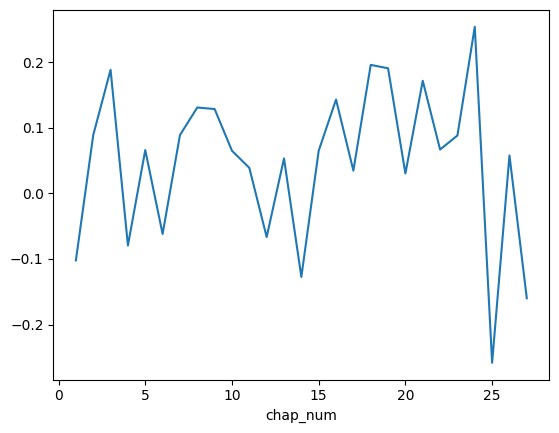

In [380]:
# test
DOC_SENT.loc['the-murder-of-roger-ackroyd']['sentiment'].plot()

In [381]:
# rewrite the plot_book_sa fuction from notes to work with NRC columns

pos_emotions = ['joy', 'anticipation', 'trust']
neg_emotions = ['anger', 'disgust', 'fear', 'sadness']
surprise_emotion = ['surprise']

def plot_book_sent(book_id):
    df = DOC_SENT.loc[book_id]
    
    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
    plt.suptitle(book_id.replace('-', ' ').title(), fontsize=16, y=1.01)
    
    # sentiment valence
    df['sentiment'].plot(ax=axes[0], color='steelblue')
    axes[0].axhline(0, color='gray', linewidth=0.8, linestyle='--')
    axes[0].set_ylabel('sentiment')

    # positive emotion dimensions
    df[pos_emotions].plot(ax=axes[1])
    axes[1].set_ylabel('positive emotions')
    
    # negative emotion dimensions
    df[neg_emotions].plot(ax=axes[2])
    axes[2].set_ylabel('negative emotions')
    axes[2].set_xlabel('chapter')

    # surprise emotion dimensions
    df[surprise_emotion].plot(ax=axes[3])
    axes[3].set_ylabel('surprise emotion')

    # align emotion subplot y-axes for honest comparison
    emotion_min = min(df[pos_emotions + neg_emotions + surprise_emotion].min().min(), 0)
    emotion_max = df[pos_emotions + neg_emotions + surprise_emotion].max().max()
    for ax in axes[1:]:
        ax.set_ylim(emotion_min, emotion_max + 0.05)
    
    plt.tight_layout()
    sns.despine()
    plt.savefig(f'plots/{book_id}_sentiment.png', dpi=150, bbox_inches='tight')
    plt.show()

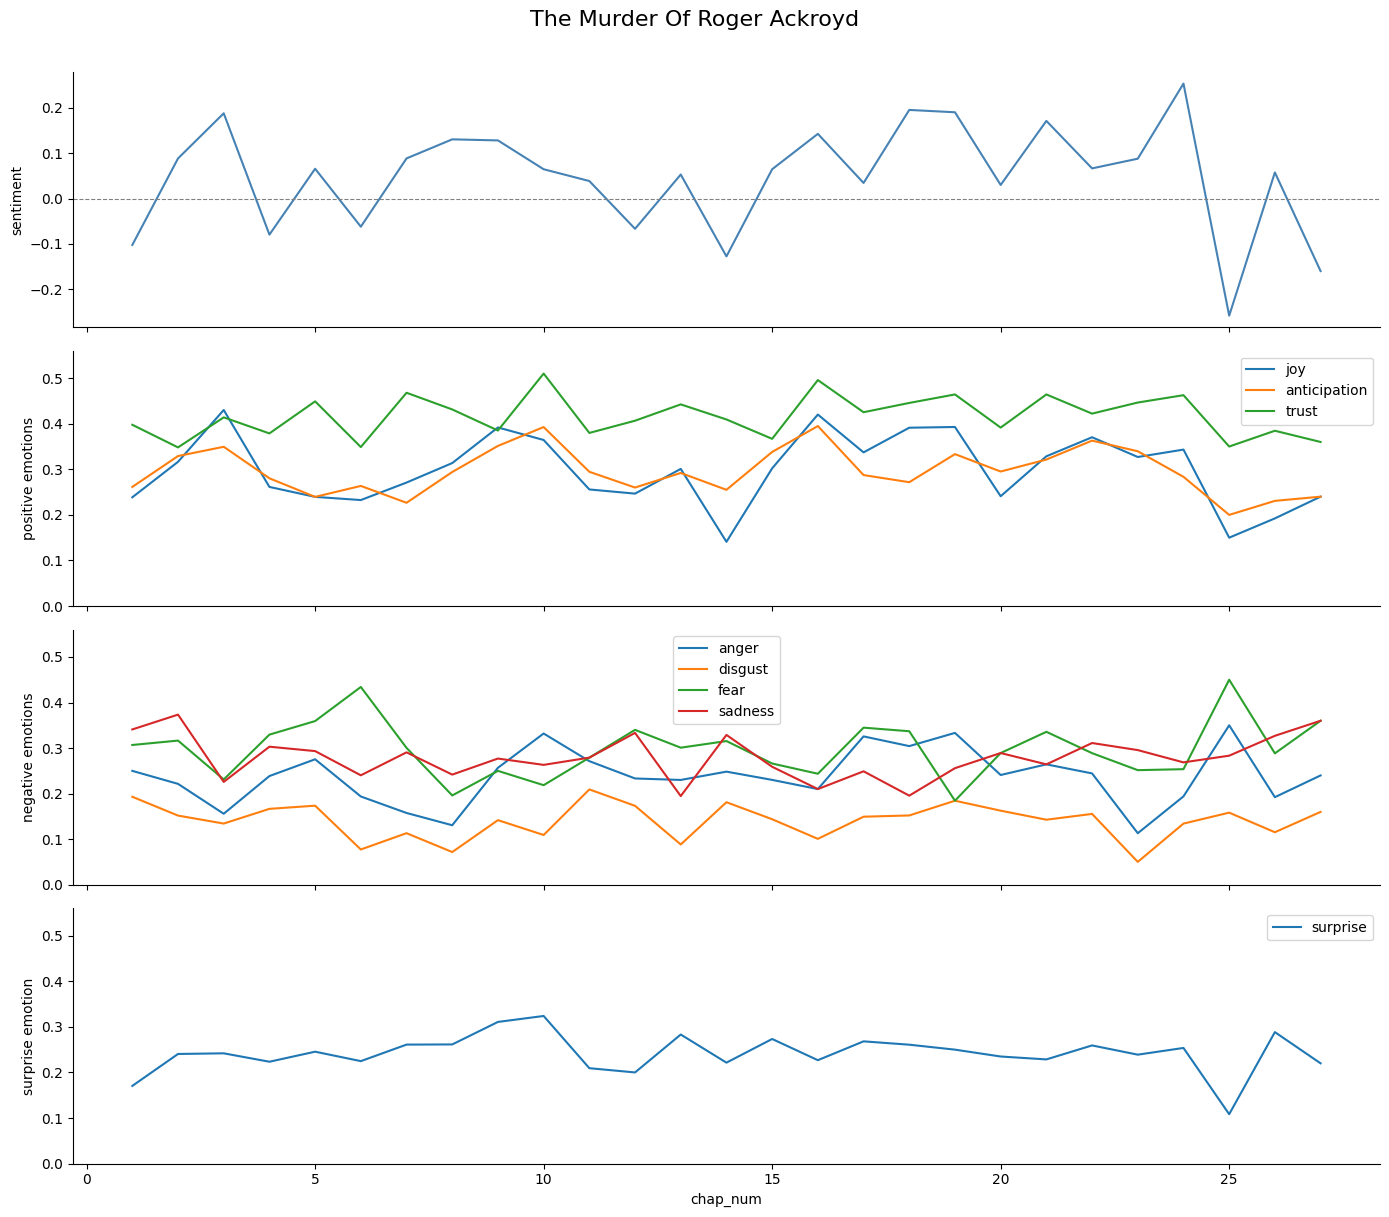

In [382]:
plot_book_sent('the-murder-of-roger-ackroyd')

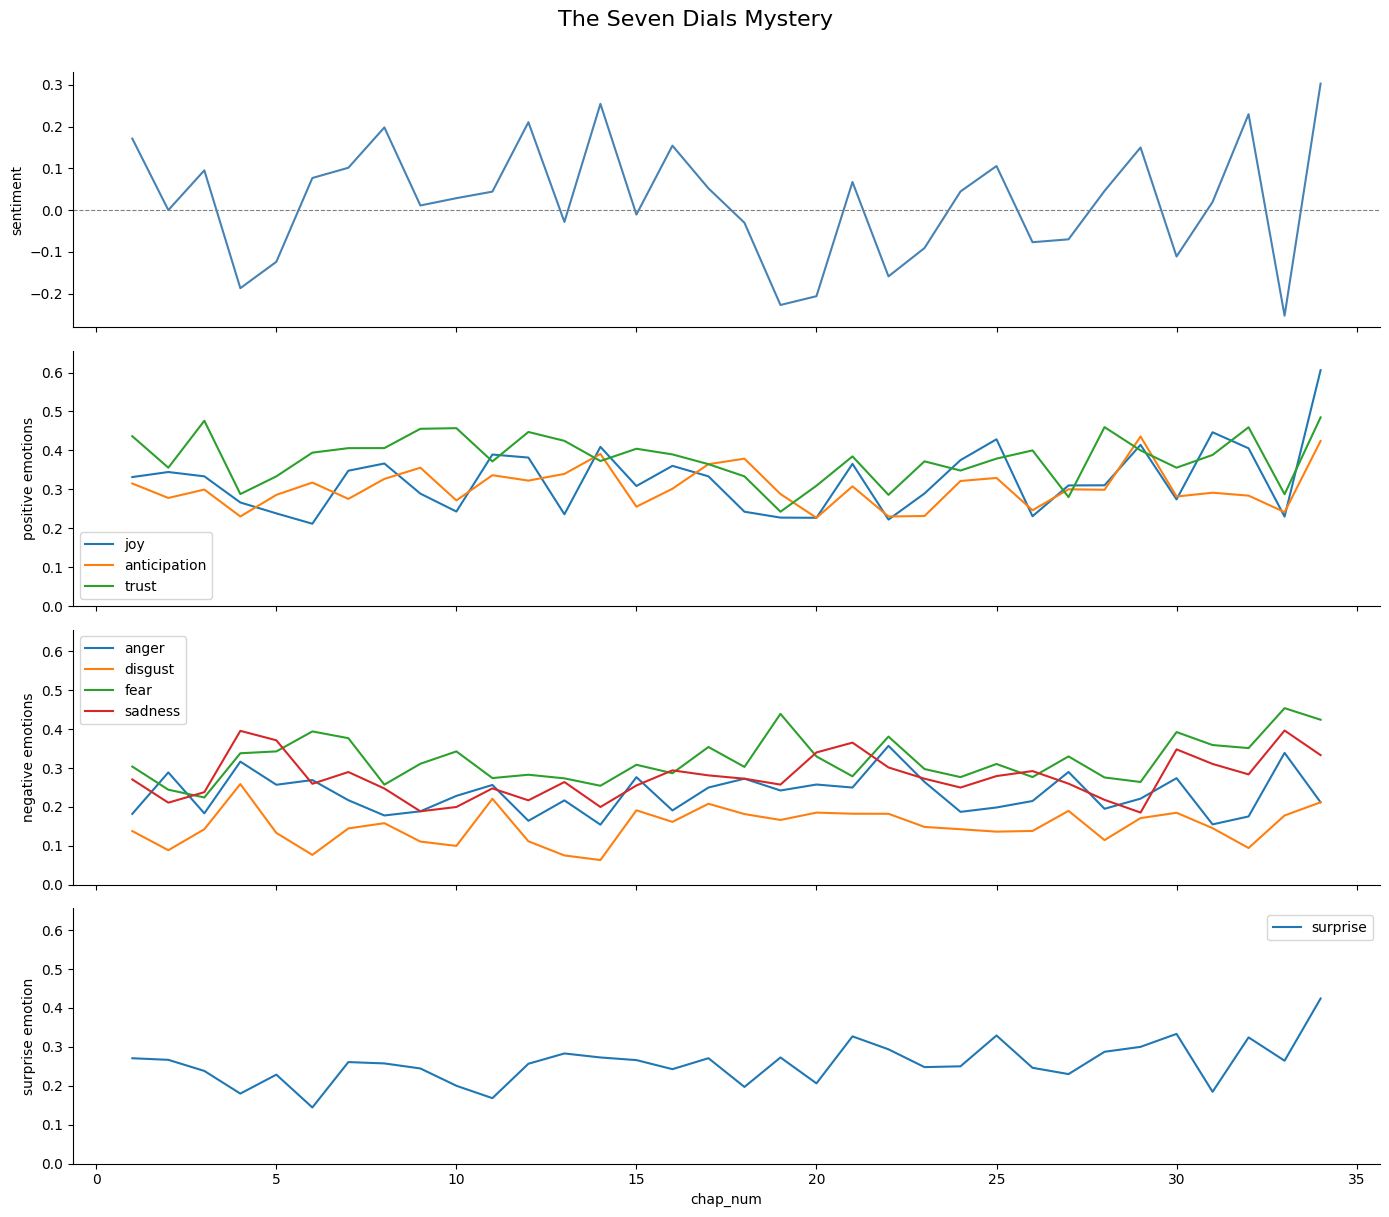

In [383]:
plot_book_sent('the-seven-dials-mystery')